In [59]:
import numpy as np
import pandas as pd
import json
import urllib.request

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
regressorRight = LinearRegression()
x_valr = np.array([50.2, 52.5])
x_valr = x_valr.reshape(-1, 1)
y_valr = np.array([0, -1])
regressorRight.fit(X=x_valr, y=y_valr)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
regressorLeft = LinearRegression()
x_vall = np.array([49.8, 47.5])
x_vall = x_vall.reshape(-1, 1)
y_vall = np.array([0,1])
regressorLeft.fit(X=x_vall, y=y_vall)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
def frequency_response(freq):
    if freq<47.5:
        return 1
    elif freq > 52.5:
        return -1
    elif freq>50.2:
        returnVal = regressorRight.predict([[freq]])
        return returnVal[0]
    elif freq<49.8:
        returnVal = regressorLeft.predict([[freq]])
        return returnVal[0]
    else: return 0

In [64]:
print(frequency_response(52.4))

-0.9565217391304337


In [65]:
freqs = np.linspace(46,54,num=81)
freq_x = pd.Series(freqs)
freq_y = freq_x.apply(frequency_response)
df_freq = pd.DataFrame({'frequency':freq_x, 'value':freq_y})
print(df_freq)

    frequency  value
0        46.0    1.0
1        46.1    1.0
2        46.2    1.0
3        46.3    1.0
4        46.4    1.0
..        ...    ...
76       53.6   -1.0
77       53.7   -1.0
78       53.8   -1.0
79       53.9   -1.0
80       54.0   -1.0

[81 rows x 2 columns]


<Axes: xlabel='frequency (Hz)'>

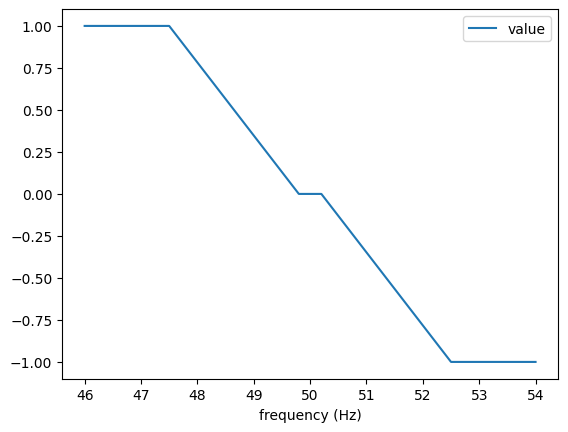

In [66]:
df_freq.set_index('frequency', inplace=True)
df_freq.plot(kind='line', xlabel = 'frequency (Hz)')

In [67]:
import unittest
class TestFrequencyResponse(unittest.TestCase):
    def test_frequency_response(self):
        self.assertEqual(frequency_response(50),0)
        self.assertEqual(frequency_response(50.2),0)
        self.assertEqual(frequency_response(49.8),0)
        self.assertEqual(frequency_response(52.6),-1)
        self.assertEqual(frequency_response(40.6), 1)
        self.assertEqual(frequency_response(51.35), -0.5)
        self.assertEqual(frequency_response(48.65), .5)

unittest.main(argv=['first-arg-is-ignored'], exit=False)

.
----------------------------------------------------------------------
Ran 1 test in 0.002s

OK
